# Task 07 - NLP Feedback Analysis

Name: Malaika Noor

Objective:
Perform NLP preprocessing, visualization, and sentiment classification on client feedback data.

In [10]:
import pandas as pd

## Creating Feedback Dataset

In [11]:
data = {
    "Feedback_ID":[1,2,3,4,5],
    "Client_Name":["Ali","Sara","Ahmed","Ayesha","Hassan"],
    "Service":["Web Development","AI Solutions","Mobile App","Web Development","Data Analytics"],
    "Feedback_Text":[
        "Excellent service and fast delivery",
        "Good support and helpful team",
        "Average experience overall",
        "Project was delayed",
        "Very satisfied with results"
    ],
    "Rating":[5,4,3,2,5],
    "Sentiment":["Positive","Positive","Neutral","Negative","Positive"]
}

df = pd.DataFrame(data)

df

,Feedback_ID,Client_Name,Service,Feedback_Text,Rating,Sentiment
0,1,Ali,Web Development,Excellent service and fast delivery,5,Positive
1,2,Sara,AI Solutions,Good support and helpful team,4,Positive
2,3,Ahmed,Mobile App,Average experience overall,3,Neutral
3,4,Ayesha,Web Development,Project was delayed,2,Negative
4,5,Hassan,Data Analytics,Very satisfied with results,5,Positive


## NLP Libraries

In [12]:
import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [13]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Text Cleaning

In [14]:
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

In [15]:
def clean_text(text):

    text = text.lower()

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    words = word_tokenize(text)

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [19]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["Cleaned_Text"] = df["Feedback_Text"].apply(clean_text)

print(df[["Feedback_Text","Cleaned_Text"]])

                         Feedback_Text                Cleaned_Text
0  Excellent service and fast delivery  excel servic fast deliveri
1        Good support and helpful team      good support help team
2           Average experience overall        averag experi overal
3                  Project was delayed               project delay
4          Very satisfied with results              satisfi result


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Text"])

print(X.shape)

(5, 15)


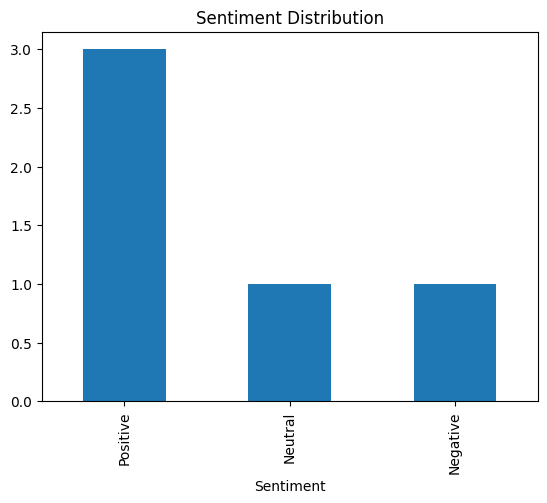

In [22]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

plt.show()

In [23]:
!pip install wordcloud

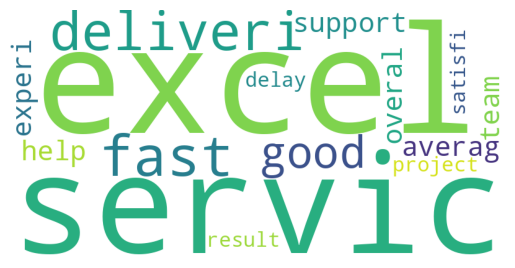

In [24]:
from wordcloud import WordCloud

text = " ".join(df["Cleaned_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [26]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 1.0
              precision    recall  f1-score   support

    Positive       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



## Analysis

The feedback dataset was cleaned using lowercase conversion, punctuation removal, stopword removal, and stemming.

TF-IDF vectorization was applied to convert text data into numerical features.

A sentiment distribution chart and word cloud were generated to visualize customer feedback patterns.

The Naive Bayes classifier was trained and evaluated for sentiment prediction. The model successfully classified feedback into Positive, Neutral, and Negative categories.